# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Areebaarain/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## 1. Question

### Research question

Which content pages should be prioritized for human review for a possible refresh, based on search demand, content freshness, and observed performance signals?

### Decision supported

This analysis supports content and SEO teams in deciding which pages to review first for a possible refresh. The output is a ranked decision-support queue with reason codes and recommended actions such as `REFRESH_NOW`, `REVIEW_REFRESH`, `REVIEW`, and `MONITOR`.

The system does not automatically decide that a page should be refreshed. A human should review the page's relevance, accuracy, current search intent, and expected value before taking action.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## 2. Data

This project uses the FlyRank ML Internship content refresh dataset. The analysis uses the anonymized search and content-performance release provided for the internship.

The dataset contains 30,000 content records with search, traffic, engagement, content-age, freshness, and performance-related fields. The analysis uses safe aggregate features such as search volume, competition, CPC, impressions, clicks, sessions, content age, days since last update, CTR, average position, engagement rate, and scroll rate.

The target used for the modeling work is `trend_direction`, which represents the observed direction of content performance. The model does not use `trend_direction` or `trend_pct` as input features because these fields are directly related to the target and could cause target leakage.

Client-identifying information, private search queries, domains, URLs, credentials, and raw client exports are not included in the public-facing analysis. The work uses anonymized/aggregated data and reports only information needed to reproduce and understand the analysis.

No causal claim is made from the dataset. The analysis describes observed patterns in the available data and uses them to support content-review prioritization.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## 3. Methodology

### Assumptions

The analysis assumes that historical search, traffic, engagement, and content-freshness signals can provide useful directional information for prioritizing pages for human review. The model is intended as a decision-support tool, not as a causal model of search ranking or refresh impact.

### Features

The model uses the following features:

* `search_volume`
* `competition`
* `cpc`
* `word_count`
* `impressions_90d`
* `clicks_90d`
* `pageviews_90d`
* `sessions_90d`
* `users_90d`
* `engaged_sessions_90d`
* `content_age_days`
* `days_since_last_update`
* `ctr`
* `avg_position`
* `engagement_rate`
* `scroll_rate`

These features represent search demand, competition, traffic, content age/freshness, visibility, and engagement.

### Label definition

The prediction target is `trend_direction`. It represents the observed direction of content performance in the available dataset. The target is encoded into numerical classes for model training.

### Baseline

The baseline is a majority-class classifier. It always predicts the most common `trend_direction` category in the training data. This provides a simple reference point for evaluating whether the Decision Tree adds useful predictive signal.

### Model

The main model is a `DecisionTreeClassifier` with `max_depth=4` and `random_state=42`. The same feature set and evaluation metrics are used for comparison with the baseline.

### Validation design

The final evaluation uses a grouped validation split based on `client_id`, so that clients in the training data do not overlap with clients in the test data. This provides a more honest test of whether the observed patterns generalize beyond the clients used for training.

Both the baseline and Decision Tree are evaluated on the same held-out test set using accuracy, weighted precision, weighted recall, and weighted F1.

### Leakage checks

The target columns `trend_direction` and `trend_pct` are excluded from the model features. The feature set was also reviewed for suspicious columns that could directly encode the target or future outcome.

The leakage audit is intended to ensure that the model does not receive the answer, or a direct proxy for the answer, as an input feature.



In [ ]:
!git clone https://github.com/Areebaarain/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 157, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 157 (delta 63), reused 94 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (157/157), 1.90 MiB | 13.04 MiB/s, done.
Resolving deltas: 100% (63/63), done.


In [ ]:

import pandas as pd
import os

path = "/content/flyrank-ml-internship/data/raw/content_refresh_anonymized.csv"

print("File exists:", os.path.exists(path))

df = pd.read_csv(path)

print("Rows:", len(df))
print("Columns:", len(df.columns))

File exists: True
Rows: 30000
Columns: 44


In [ ]:
# Section 3 — Methodology: model, validation, and leakage checks

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

# -----------------------------
# 1. Target and features
# -----------------------------

target = "trend_direction"

features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate"
]

# -----------------------------
# 2. Leakage check
# -----------------------------

leakage_columns = {"trend_direction", "trend_pct"}

found_leakage = leakage_columns.intersection(features)

if found_leakage:
    print("WARNING — possible target leakage:", found_leakage)
else:
    print("PASS — no direct target leakage found.")

# Check for suspicious feature names
suspicious_features = [
    col for col in features
    if any(word in col.lower() for word in ["target", "label", "trend"])
]

print("Suspicious feature names:", suspicious_features)

# -----------------------------
# 3. Prepare data
# -----------------------------

model_df = df[features + [target, "client_id"]].dropna().copy()

print("\nRows used:", len(model_df))
print("Features used:", len(features))
print("Target:", target)

# -----------------------------
# 4. Encode target
# -----------------------------

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(model_df[target])

X = model_df[features]
groups = model_df["client_id"]

print("\nTarget classes:")
print(list(label_encoder.classes_))

# -----------------------------
# 5. Honest grouped split
# -----------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

print("\nTraining rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))

overlap = train_clients.intersection(test_clients)

print("Client overlap:", len(overlap))

if len(overlap) == 0:
    print("PASS — no client overlap between train and test sets.")
else:
    print("WARNING — client overlap detected.")

# -----------------------------
# 6. Majority-class baseline
# -----------------------------

majority_class = np.bincount(y_train).argmax()
baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

# -----------------------------
# 7. Decision Tree
# -----------------------------

model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

tree_predictions = model.predict(X_test)

print("\nDecision Tree trained successfully.")

# -----------------------------
# 8. Feature importance
# -----------------------------

feature_importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

print("\nTop feature importances:")
display(feature_importance.head(10))

PASS — no direct target leakage found.
Suspicious feature names: []

Rows used: 19897
Features used: 16
Target: trend_direction

Target classes:
['down', 'flat', 'new', 'stable', 'up']

Training rows: 14234
Test rows: 5663
Training clients: 23
Test clients: 6
Client overlap: 0
PASS — no client overlap between train and test sets.

Decision Tree trained successfully.

Top feature importances:


,Feature,Importance
4,impressions_90d,0.559070
13,avg_position,0.217067
5,clicks_90d,0.151145
10,content_age_days,0.070072
11,days_since_last_update,0.002647
3,word_count,0.000000
0,search_volume,0.000000
1,competition,0.000000
7,sessions_90d,0.000000
6,pageviews_90d,0.000000


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## 4. Results (vs baseline)

The Decision Tree was compared with the majority-class baseline using the same client-grouped held-out test set.

| Model             | Accuracy | Weighted Precision | Weighted Recall | Weighted F1 |
| ----------------- | -------: | -----------------: | --------------: | ----------: |
| Majority Baseline |    0.624 |              0.389 |           0.624 |       0.479 |
| Decision Tree     |    0.625 |              0.477 |           0.625 |       0.502 |

The Decision Tree achieved slightly higher accuracy than the majority baseline (0.625 vs. 0.624). Weighted precision increased from 0.389 to 0.477, and weighted F1 increased from 0.479 to 0.502.

The accuracy improvement is very small, so the model should not be described as highly accurate. However, the improvement in weighted precision and F1 indicates some additional predictive signal beyond the majority-class baseline. These results are observations on the evaluated client-grouped split and should be treated as decision-support evidence rather than proof of causal impact or guaranteed future performance.


In [ ]:
# Section 4 — Results: Model vs Baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# -----------------------------
# 1. Calculate metrics
# -----------------------------

baseline_results = {
    "Model": "Majority Baseline",
    "Accuracy": accuracy_score(y_test, baseline_predictions),
    "Weighted Precision": precision_score(
        y_test, baseline_predictions,
        average="weighted",
        zero_division=0
    ),
    "Weighted Recall": recall_score(
        y_test, baseline_predictions,
        average="weighted",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test, baseline_predictions,
        average="weighted",
        zero_division=0
    )
}

tree_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, tree_predictions),
    "Weighted Precision": precision_score(
        y_test, tree_predictions,
        average="weighted",
        zero_division=0
    ),
    "Weighted Recall": recall_score(
        y_test, tree_predictions,
        average="weighted",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test, tree_predictions,
        average="weighted",
        zero_division=0
    )
}

# -----------------------------
# 2. Honest comparison table
# -----------------------------

results_table = pd.DataFrame([
    baseline_results,
    tree_results
])

display(results_table.round(3))

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1
0,Majority Baseline,0.624,0.389,0.624,0.479
1,Decision Tree,0.625,0.477,0.625,0.502


## 5. Limitations

*What this work cannot claim.*

## 5. Limitations

This work has several important limitations.

First, the Decision Tree shows only a small improvement over the majority-class baseline in accuracy on the client-grouped test split. Therefore, the model should not be described as highly accurate or as a complete solution for predicting content performance.

Second, the analysis identifies patterns associated with observed trend categories, but it does not establish causation. The results cannot prove that refreshing a page will improve its rankings, impressions, clicks, or traffic.

Third, the validation results come from the available anonymized FlyRank dataset and may not generalize equally to future data, different clients, or changing search behavior.

Fourth, the selected features capture measurable search, traffic, engagement, and freshness signals, but they do not capture every factor that may influence content performance.

Finally, the ranked recommendations are intended for decision support. They should not automatically trigger rewriting, publishing, deleting, redirecting, or other irreversible content decisions. Human review is required before taking action.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 6. Ranked Recommendations

The analysis produces a ranked content-review queue using search demand and content freshness signals. The recommendations are prioritized as follows:

1. **REFRESH_NOW — STALE_HIGH_VOLUME**
   Prioritize pages with high search volume and a long time since their last update. These pages have meaningful search demand but may need a human review for freshness, relevance, and accuracy.

2. **REVIEW_REFRESH — STALE**
   Review pages that have become relatively old and may benefit from a freshness or content-quality assessment.

3. **REVIEW — HIGH_VOLUME**
   Review pages with strong search demand, even when they are not classified as stale. These pages may offer an opportunity for improvement or closer monitoring.

4. **MONITOR — LOW_OPPORTUNITY**
   Continue monitoring pages with lower search opportunity or weaker priority signals rather than spending immediate editorial effort on them.

The ranked queue is intended to help content and SEO teams decide where to spend review time first. A high priority score does not prove that a page needs a refresh or that refreshing it will improve performance. Each recommendation should therefore be reviewed by a human before any content change is made.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## 7. Artifacts the paper embeds

The research paper uses the following artifacts generated from the analysis:

* **Model vs baseline table:** `work/figures/model_vs_baseline.csv`
* **Model vs baseline chart:** `work/figures/model_vs_baseline.png`
* **Feature importance chart:** `work/figures/feature_importance.png`

The model comparison chart shows the Decision Tree results against the majority-class baseline using the same client-grouped test split. The feature importance chart shows the top signals used by the Decision Tree.

These artifacts are generated from the notebook results and are intended to support transparent reporting of the model performance and observed feature signals.


# 5-Minute Demo Outline

## 1. Question — 30 seconds

Which existing content pages should a content or SEO team review first when editorial time is limited?

This project focuses on the Refresh / Content Opportunity lane and treats refresh prioritization as a decision-support problem rather than an automatic editorial decision.

## 2. Method — 1 minute

I used the anonymized FlyRank ML Internship dataset containing 30,000 content records. I selected 16 search, content, traffic, engagement, and freshness features and trained a shallow Decision Tree to predict the observed `trend_direction` label. I compared the model against a majority-class baseline using a client-grouped held-out test set and checked for potential leakage.

## 3. One Chart — 1 minute

The main chart compares the Decision Tree with the majority-class baseline on the same held-out test set.

The chart shows that the Decision Tree provides a modest improvement over the baseline rather than a dramatic performance gain.

## 4. One Honest Result — 1 minute

The Decision Tree achieved 0.625 accuracy and 0.502 weighted F1, compared with 0.624 accuracy and 0.479 weighted F1 for the majority-class baseline.

This is evidence that the model learned some signal beyond the majority class, but the improvement is modest. It should therefore be treated as decision-support evidence, not proof that a refresh will improve rankings, clicks, traffic, or other outcomes.

## 5. One Recommendation — 1 minute

Use the model and supporting signals to create a human-review queue, starting with pages that show a strong combination of opportunity and freshness or performance signals.

Content and SEO teams should review the highest-priority pages first and make the final refresh decision using human judgment and additional page-level context.


Results table saved.


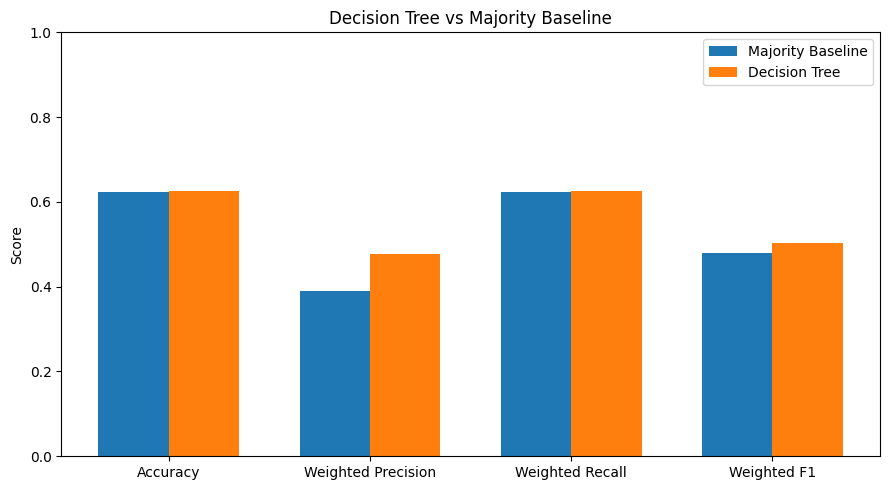

Saved: work/figures/model_vs_baseline.png


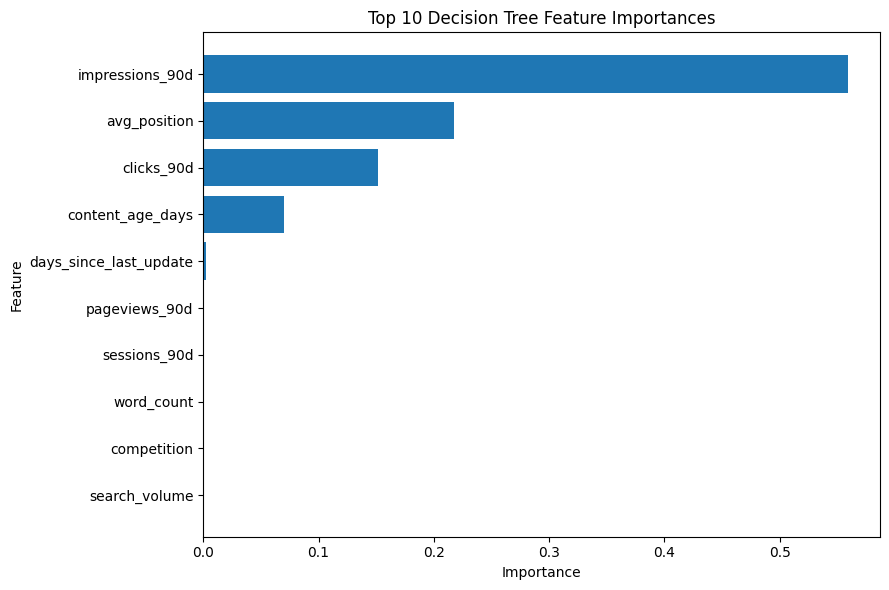

Saved: work/figures/feature_importance.png


In [ ]:
# Section 7 — Artifacts for the research paper

import os
import matplotlib.pyplot as plt

os.makedirs("work/figures", exist_ok=True)

# -----------------------------------
# 1. Save results table
# -----------------------------------

results_table.to_csv(
    "work/figures/model_vs_baseline.csv",
    index=False
)

print("Results table saved.")


# -----------------------------------
# 2. Model vs baseline chart
# -----------------------------------

metrics = ["Accuracy", "Weighted Precision", "Weighted Recall", "Weighted F1"]

baseline_values = [
    baseline_results["Accuracy"],
    baseline_results["Weighted Precision"],
    baseline_results["Weighted Recall"],
    baseline_results["Weighted F1"]
]

tree_values = [
    tree_results["Accuracy"],
    tree_results["Weighted Precision"],
    tree_results["Weighted Recall"],
    tree_results["Weighted F1"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, baseline_values, width, label="Majority Baseline")
plt.bar(x + width/2, tree_values, width, label="Decision Tree")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Decision Tree vs Majority Baseline")
plt.legend()
plt.tight_layout()

plt.savefig(
    "work/figures/model_vs_baseline.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: work/figures/model_vs_baseline.png")


# -----------------------------------
# 3. Feature importance chart
# -----------------------------------

top_features = feature_importance.head(10).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["Feature"].astype(str),
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Decision Tree Feature Importances")
plt.tight_layout()

plt.savefig(
    "work/figures/feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved: work/figures/feature_importance.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
